## A06b

In [1]:
# import pandas --- spreadsheet library
import pandas as pd

import numpy as np

# import matplotlib --- plotting library
import matplotlib.pyplot as plt

from plotting import make_overview, compare
from myio import read_in_weather_data

In [2]:
%matplotlib inline

In [3]:
import os

fdir = '../../Data/Calibration Data/Agrifood/Clean data'

fpath = os.path.join(fdir,'Yield/KBL - 2006.csv')
dfo = pd.read_csv(fpath)
dfo = dfo.set_index(pd.to_datetime(dfo['Month']))
dfo = dfo.dropna(how='all')

fpath = os.path.join(fdir, 'Weather/A06b.csv')
dfw = read_in_weather_data(fpath)

In [4]:
dfo = dfo.dropna(how='all')

In [5]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField

# 1. Initialize the model
dt = 10

p = PalmField(year_of_planting=2004, month_of_planting=1, dt=dt)
p.soil.parameters['water_holding_capacity']['value'] = 500

# 2. Couple the solar radiation data:
dfw = dfw.resample('D').pad()
dfw = dfw.rolling(dt, center=True).mean()
dfw = dfw.fillna(method='pad')

p.weather.radiation_series = dfw['Solar']
p.weather.rainfall_series = dfw['Precip']
p.weather.humidity_series = dfw['RelHum']

nyears = 18

duration = nyears*365

df = p.run(duration=duration)

Saving as: A06b.png


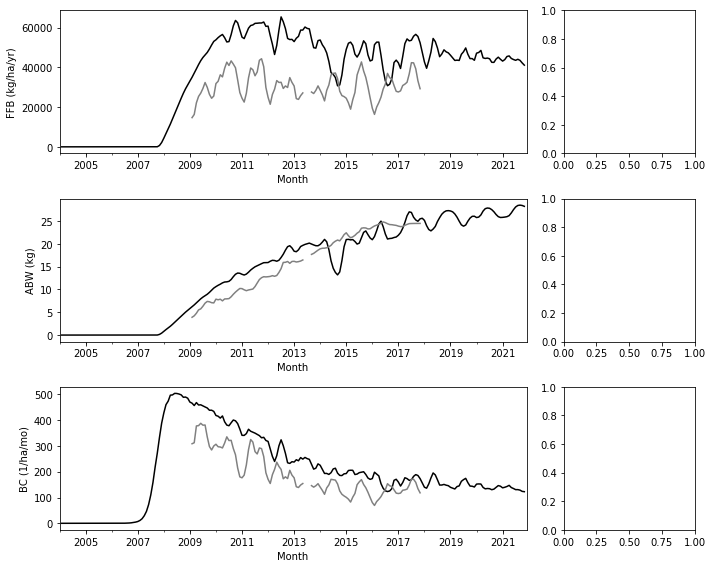

In [6]:
sname = 'A06b'

make_overview(df, dfo, sname, window=3)

Saving as: A06b.png


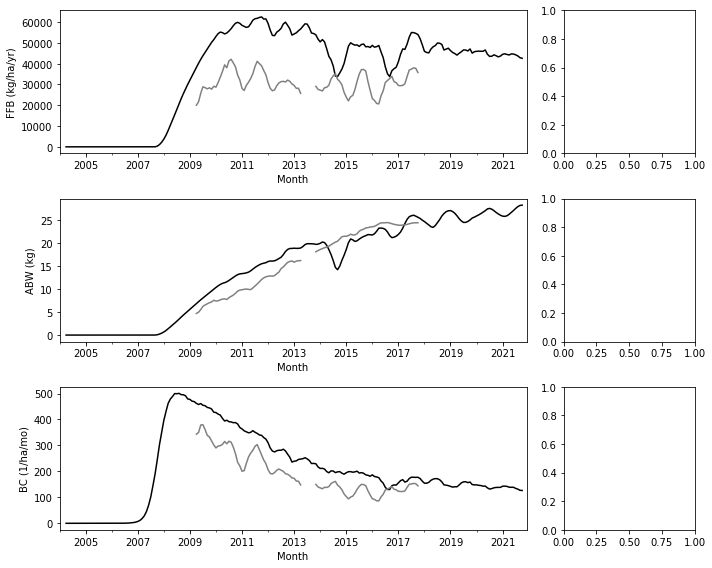

In [7]:
make_overview(df, dfo, sname, window=6)

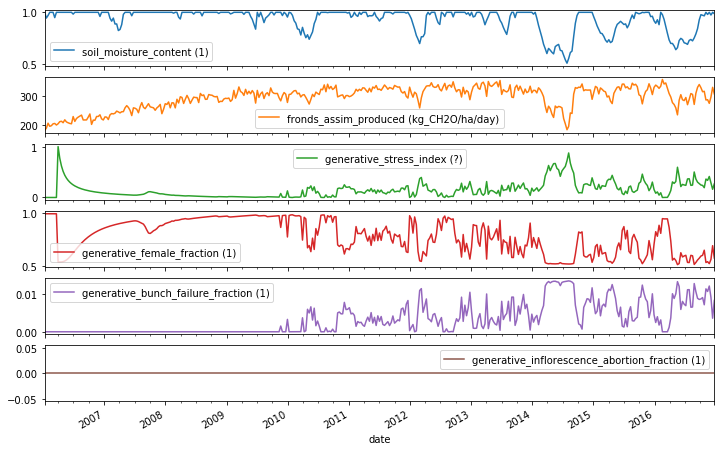

In [8]:
cs = ['soil_moisture_content (1)',
      'fronds_assim_produced (kg_CH2O/ha/day)',
      'generative_stress_index (?)',
      'generative_female_fraction (1)',
      'generative_bunch_failure_fraction (1)',
     'generative_inflorescence_abortion_fraction (1)']

df.loc['2006':'2016',cs].plot(subplots=True, figsize=(12,8));